# Reprodução do modelo isobárico — Square Dalitz (0, 1): $B^{\pm}\to\pi^{\pm}\pi^+\pi^-$

O benchmark de amplitudes de sinal usa como referência a análise LHCb publicada em [Phys. Rev. D 101, 012006](https://cds.cern.ch/record/2689374/files/1909.05212.pdf).

O objetivo inicial é avaliar os coeficientes cartesianos publicados e calcular as fit fractions por carga e as assimetrias $A_{CP}$. A reprodução estatística do ajuste experimental exige os eventos de dados da análise; este notebook valida a álgebra de amplitudes e a normalização do fitter.

Cópia de `paper_isobar_benchmark_squaredp_01.ipynb` com integração em Square Dalitz: `normalization_method="square-dalitz"`, `normalization_pair=(0, 1)`.

**Esta é uma cópia que também realiza ajustes, apenas com amostras de sinal puro, nível de geração.** O benchmark de amplitudes acima é preservado sem alteração; a seção original de toy closure com eficiência/background/veto artificiais foi removida — esta cópia não usa nenhuma forma de eficiência, background ou veto em nenhum momento. Duas seções novas foram acrescentadas ao final:

1. **Comparação com um toy do Laura++** — carrega um toy gerado externamente pelo Laura++ com exatamente este modelo (`gen-3pi_toy0.root`, árvore `genResults`) e compara suas projeções e o Dalitz plot com um toy gerado pelo nosso fitter usando os mesmos coeficientes publicados. Ambas as amostras são geração pura, sem seleção.
2. **Ajuste do ensemble de toys do Laura++** — ajusta cada um dos $N$ toys do Laura++ (`gen-3pi_toy0.root` a `gen-3pi_toy{N-1}.root`) com os coeficientes cartesianos livres e verifica a recuperação dos valores publicados via pulls, em várias amostras independentes.

O caminho da pasta com os arquivos ROOT do Laura++ é configurável na primeira célula de código da seção 1.


## Convenções

Para cada componente, usamos a convenção da Tabela XXI:

$$c_q=(x+q\,\delta x)+i(y+q\,\delta y),\qquad q=+1\;(B^+),\;q=-1\;(B^-).$$

A contribuição $\rho(770)^0-\omega(782)$ é agrupada incluindo o termo de interferência entre os dois componentes.

Orientação angular: `pair=(2, 0)` usa a partícula 3 para definir o ângulo com a bachelor 2, como `LauKinematics::calcHelicities` para o par 1,3. A simetrização gera o par 3,2 com a mesma orientação. Inverter essa ordem muda o sinal das ondas ímpares relativamente às pares.

In [1]:
import sys
from pathlib import Path

# Make the notebook work from the repository or from notebooks/benchmark.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "dalitzplotfitter").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break

import numpy as np
import pandas as pd

from dalitzplotfitter import (
    DecayChannel, DecayModel, GounarisSakurai, PipiKKRescattering,
    RealImag, RelativisticBreitWigner, Resonance,
    SigmaPole, enable_x64, ZemachP
)

enable_x64()

In [2]:
# O notebook é autocontido: não depende de um módulo Python externo.
# Massas/larguras em GeV. A fonte dos números está documentada na célula seguinte.
RESCATTERING_CONVENTION = "laura"  # "paper" reproduz a expressão impressa
PAPER_MASS_WIDTHS = {
    "rho770": (0.7708, 0.1534),       # ajuste isobárico, Tabela XX
    "omega782": (0.78265, 0.00849),   # Laura++/PDG
    "f2_1270": (1.256, 0.1867),      # ajuste isobárico,
    "rho1450": (1.465, 0.400),        # Laura++/PDG
    "rho3_1690": (1.686, 0.186),      # Laura++/PDG
    "sigma": (0.563, 0.350),          # polo ajustado, Tabela XXII
}
COEFFICIENTS = {
    "rho770": (1.000, 0.000, -0.003, 0.000),
    "omega782": (0.091, -0.007, 0.000, -0.022),
    "f2_1270": (0.291, 0.204, -0.002, -0.179),
    "rho1450": (-0.223, 0.191, 0.031, 0.068),
    "rho3_1690": (0.073, -0.045, 0.044, -0.013),
    "rescattering": (0.142, -0.040, -0.047, -0.027),
    "sigma": (-0.485, 0.284, 0.231, 0.270),
}
def coefficient(name, charge):
    x, y, dx, dy = COEFFICIENTS[name]
    return complex(x + charge * dx, y + charge * dy)

def components(charge):
    c = {name: coefficient(name, charge) for name in COEFFICIENTS}
    rho_mass, rho_width = PAPER_MASS_WIDTHS["rho770"]
    omega_mass, omega_width = PAPER_MASS_WIDTHS["omega782"]
    f2_mass, f2_width = PAPER_MASS_WIDTHS["f2_1270"]
    rho1450_mass, rho1450_width = PAPER_MASS_WIDTHS["rho1450"]
    rho3_mass, rho3_width = PAPER_MASS_WIDTHS["rho3_1690"]
    sigma_mass, sigma_width = PAPER_MASS_WIDTHS["sigma"]
    return [
        # Laura++ 3.8 examples/GenFit3pi.cc -- the actual generator config for
        # the gen-3pi_toy*.root samples -- uses independent GS(rho)/RelBW(omega)
        # resonances, each with its own CP coefficient, not a combined
        # rho-omega mixing lineshape.
        Resonance("rho770", (2, 0), RealImag(c["rho770"].real, c["rho770"].imag),
                  lineshape=GounarisSakurai(),
                  mass=rho_mass, width=rho_width, spin=1, angular=ZemachP(),
                  resonance_radius=4.0, parent_radius=4.0),
        Resonance("omega782", (2, 0), RealImag(c["omega782"].real, c["omega782"].imag),
                  lineshape=RelativisticBreitWigner(),
                  mass=omega_mass, width=omega_width, spin=1, angular=ZemachP(),
                  resonance_radius=4.0, parent_radius=4.0),
        Resonance("f2_1270", (2, 0), RealImag(c["f2_1270"].real, c["f2_1270"].imag),
                  lineshape=RelativisticBreitWigner(), mass=f2_mass, width=f2_width,
                  spin=2, angular=ZemachP(), resonance_radius=4.0, parent_radius=4.0),
        Resonance("rho1450", (2, 0), RealImag(c["rho1450"].real, c["rho1450"].imag),
                  lineshape=RelativisticBreitWigner(), mass=rho1450_mass, width=rho1450_width,
                  spin=1, angular=ZemachP(), resonance_radius=4.0, parent_radius=4.0),
        Resonance("rho3_1690", (2, 0), RealImag(c["rho3_1690"].real, c["rho3_1690"].imag),
                  lineshape=RelativisticBreitWigner(), mass=rho3_mass, width=rho3_width,
                  spin=3, angular=ZemachP(), resonance_radius=4.0, parent_radius=4.0),
        # Rescattering não tem polo: 1.0--1.5 GeV é a janela da parametrização.
        # GenFit3pi.cc não chama setResonanceParameter para "Rescattering", ou
        # seja, usa os padrões do próprio LauRescatteringRes: lambdaPiPi=1.0
        # (= delta_pipi_squared=1.0, já o padrão da classe) e lambdaKK=2.8
        # (= delta_kk_squared=7.84, explícito abaixo -- o padrão da classe,
        # 1.0, não reproduz esse valor).
        Resonance("rescattering", (2, 0), RealImag(c["rescattering"].real, c["rescattering"].imag),
                  lineshape=PipiKKRescattering(convention=RESCATTERING_CONVENTION,
                                               delta_kk_squared=2.8 ** 2),
                  mass=1.0, width=0.0, spin=0,
                  resonance_radius=4.0, parent_radius=4.0),
        Resonance("sigma", (2, 0), RealImag(c["sigma"].real, c["sigma"].imag),
                  lineshape=SigmaPole(), mass=sigma_mass, width=sigma_width, spin=0,
                  angular=ZemachP(), resonance_radius=4.0, parent_radius=4.0),
    ]

def make_model(charge, resolution):
    pion = "pi+" if charge > 0 else "pi-"
    other = "pi-" if charge > 0 else "pi+"
    return DecayModel(DecayChannel("B+" if charge > 0 else "B-", (pion, pion, other)), components(charge), normalization_method="square-dalitz", normalization_resolution=resolution, normalization_pair=(0, 1), normalize_components=True)

## Massas e larguras usadas

A massa e a largura do $\rho(770)^0$ são os valores ajustados no isobárico (Tabela XX), e os parâmetros do polo $\sigma$ vêm da Tabela XXII. Para $\omega(782)$, $f_2(1270)$, $\rho(1450)^0$ e $\rho_3(1690)^0$, a Tabela III especifica as linhashapes mas não imprime os números: usamos os valores nominais do catálogo Laura++/PDG. O rescattering não recebe massa/largura de ressonância; sua parametrização é definida na janela $1{,}0<m<1{,}5$ GeV.

In [3]:
mass_widths = pd.DataFrame.from_dict(
    PAPER_MASS_WIDTHS, orient="index", columns=["mass [GeV]", "width [GeV]"]
)
mass_widths.index.name = "component"
mass_widths

,mass [GeV],width [GeV]
component,,
rho770,0.77080,0.15340
omega782,0.78265,0.00849
f2_1270,1.25600,0.18670
rho1450,1.46500,0.40000
rho3_1690,1.68600,0.18600
sigma,0.56300,0.35000


## Convenção do rescattering e configuração completa do gerador

A opção `RESCATTERING_CONVENTION="laura"` usa a fase global $i$ e o fator de produção $[(1+s/\lambda_{\pi\pi}^2)(1+s/\lambda_{KK}^2)]^{-1}$, $s=m^2$, do `LauRescatteringRes.cc` local (Laura++ 3.8). A opção `"paper"` mantém a expressão impressa. Ambas mantêm aqui a janela 1.0–1.5 GeV; o Laura++ original começa no limiar KK.

A configuração completa do gerador é `Laura++/examples/GenFit3pi.cc` (Laura++ 3.8), que reproduz explicitamente o modelo CP-violador de B -> 3pi da análise LHCb: $\rho(770)^0$ usa Gounaris-Sakurai e $\omega(782)$ usa Breit-Wigner relativística **como componentes independentes**, cada um com seu próprio coeficiente CP — não uma lineshape combinada de mistura $\rho$-$\omega$ (`RhoOmegaMixing`, usada em uma versão anterior deste notebook, foi removida). O rescattering usa os parâmetros extra padrão de `LauRescatteringRes` (`lambdaPiPi=1.0`, `lambdaKK=2.8`), não os padrões neutros de `PipiKKRescattering` (`delta_pipi_squared=delta_kk_squared=1.0`); por isso `delta_kk_squared=2.8**2` é passado explicitamente acima. As demais massas, larguras, raios de barreira e coeficientes centrais/eixos fixos de `GenFit3pi.cc` já coincidiam com os valores usados aqui.

Os resultados históricos de convergência no plano de massas estão no notebook original (`paper_isobar_benchmark.ipynb`); as tabelas desta cópia são recalculadas com integração Square Dalitz no par `(0, 1)`. A convergência desta malha deve ser avaliada separadamente.


## Coeficientes cartesianos publicados

Os valores abaixo são os centrais da Tabela XXI. Os componentes de erro não são usados nesta primeira etapa.

In [4]:
coefficients = pd.DataFrame(
    COEFFICIENTS, index=["x", "y", "dx", "dy"]
).T
coefficients

,x,y,dx,dy
rho770,1.000,0.000,-0.003,0.000
omega782,0.091,-0.007,0.000,-0.022
f2_1270,0.291,0.204,-0.002,-0.179
rho1450,-0.223,0.191,0.031,0.068
rho3_1690,0.073,-0.045,0.044,-0.013
rescattering,0.142,-0.040,-0.047,-0.027
sigma,-0.485,0.284,0.231,0.270


## Construção dos modelos $B^+$ e $B^-$

`resolution` controla a resolução da quadratura Square Dalitz em $(m′, \theta′)$, com `normalization_pair=(0, 1)` explícito (o par dos píons de mesma carga). A malha integra o quadrado completo com o Jacobiano físico. Compare resoluções 1000, 1400 e 2000 para estudar convergência.

O par da integração é independente do par `(2, 0)` das amplitudes ressonantes. Os plots dobrados continuam sendo apenas representações dos dados e do ajuste.


In [5]:
resolution = 1000
plus_model = make_model(+1, resolution)
minus_model = make_model(-1, resolution)

print("B+ components:", [c.name for c in plus_model.amplitude_model.components])
print("B- components:", [c.name for c in minus_model.amplitude_model.components])

B+ components: ['rho770', 'omega782', 'f2_1270', 'rho1450', 'rho3_1690', 'rescattering', 'sigma']
B- components: ['rho770', 'omega782', 'f2_1270', 'rho1450', 'rho3_1690', 'rescattering', 'sigma']


In [6]:
def fractions_and_interference(model):
    cache = model._fraction_cache(None, None)
    fractions = np.asarray(cache.fit_fractions({})) * 100.0
    interference = np.asarray(cache.interference_fractions({})) * 100.0
    names = [component.name for component in cache.components]
    result = dict(zip(names, fractions, strict=True))
    result["rho770_omega782"] = (
        result["rho770"] + result["omega782"] + interference[0, 1]
    )
    return result, interference

plus_fractions, plus_interference = fractions_and_interference(plus_model)
minus_fractions, minus_interference = fractions_and_interference(minus_model)

INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 1000 x 1000 grid.


## Fit fractions por carga

O valor diagonal de cada componente, agrupando $\rho(770)^0$-$\omega(782)$ com seu termo de interferência. A soma das frações não precisa ser 100%, porque os demais termos de interferência não estão incluídos nas frações diagonais. A comparação numérica com o Laura++ está na seção "Fit fractions e DP Rate" mais abaixo, com a matriz completa `(i,j)`.

In [7]:
fraction_names = [
    "rho770_omega782", "f2_1270", "rho1450",
    "rho3_1690", "rescattering", "sigma",
]
fractions = pd.DataFrame({
    "B+ [%]": [plus_fractions[n] for n in fraction_names],
    "B- [%]": [minus_fractions[n] for n in fraction_names],
}, index=fraction_names)
fractions.round(4)

,B+ [%],B- [%]
rho770_omega782,61.0291,55.7996
f2_1270,4.7573,11.8452
rho1450,5.8766,4.0570
rho3_1690,0.9641,0.0950
rescattering,0.7640,1.8282
sigma,20.9992,26.1241


## Frações de interferência

A matriz abaixo contém os termos $2\operatorname{Re}(A_iA_j^*)$ normalizados pela intensidade total. Ela é necessária para verificar a contribuição agrupada $\rho-\omega$ e a soma total do modelo.

In [8]:
component_names = [c.name for c in plus_model.amplitude_model.components]
plus_interference_table = pd.DataFrame(plus_interference, index=component_names, columns=component_names)
minus_interference_table = pd.DataFrame(minus_interference, index=component_names, columns=component_names)

print("B+ interference fractions [%]")
display(plus_interference_table.round(4))
print("B- interference fractions [%]")
display(minus_interference_table.round(4))

B+ interference fractions [%]


,rho770,omega782,f2_1270,rho1450,rho3_1690,rescattering,sigma
rho770,0.0000,4.3164,-1.7146,8.2892,0.7628,-0.5971,1.1833
omega782,4.3164,0.0000,-0.0389,0.1402,0.0203,-0.0087,0.0611
f2_1270,-1.7146,-0.0389,0.0000,-0.3921,-0.2057,0.1287,-0.1728
rho1450,8.2892,0.1402,-0.3921,0.0000,0.1153,-0.1515,-2.3987
rho3_1690,0.7628,0.0203,-0.2057,0.1153,0.0000,0.0097,0.3191
rescattering,-0.5971,-0.0087,0.1287,-0.1515,0.0097,0.0000,0.2602
sigma,1.1833,0.0611,-0.1728,-2.3987,0.3191,0.2602,0.0000


B- interference fractions [%]


,rho770,omega782,f2_1270,rho1450,rho3_1690,rescattering,sigma
rho770,0.0000,4.1213,-1.2951,1.8920,0.1960,-0.3783,5.3733
omega782,4.1213,0.0000,-0.0415,0.1046,0.0043,-0.0106,0.1066
f2_1270,-1.2951,-0.0415,0.0000,-0.8173,-0.0132,0.4245,-1.0188
rho1450,1.8920,0.1046,-0.8173,0.0000,-0.0393,-0.2174,-1.8370
rho3_1690,0.1960,0.0043,-0.0132,-0.0393,0.0000,0.0296,0.1871
rescattering,-0.3783,-0.0106,0.4245,-0.2174,0.0296,0.0000,-2.3987
sigma,5.3733,0.1066,-1.0188,-1.8370,0.1871,-2.3987,0.0000


## Assimetria $A_{CP}$

Usamos os coeficientes cartesianos definidos acima e a Eq. (33) do paper:

$$A_{CP}^j = \frac{|c_j^-|^2-|c_j^+|^2}{|c_j^-|^2+|c_j^+|^2}.$$

A assimetria entre fit fractions tem denominadores totais diferentes e não representa este observável.


In [9]:
acp_names = list(COEFFICIENTS)
acp = pd.DataFrame({
    "A_CP [%]": [
        100.0 * (abs(coefficient(n, -1))**2 - abs(coefficient(n, +1))**2) /
        (abs(coefficient(n, -1))**2 + abs(coefficient(n, +1))**2)
        for n in acp_names
    ],
}, index=acp_names)
acp.round(4)

,A_CP [%]
rho770,0.6000
omega782,-3.4944
f2_1270,46.8581
rho1450,-13.2360
rho3_1690,-80.2833
rescattering,45.2919
sigma,15.9926


## Fit fractions e DP Rate: comparação direta com o log do Laura++

Os valores abaixo vêm diretamente do log do gerador (`LauIsobarDynamics::initialise`,
`Initial fit fraction for amplitude (i,j)` e `Initial DPRate`), não dos números
arredondados do paper: a matriz completa `(i,j)` de fit fractions/interferência e o
DP Rate total, na ordem `[rho770, omega782, f2_1270, rho1450, rho3_1690, rescattering,
sigma]` (índices 0-6 do log, mesma ordem de `COEFFICIENTS`/`make_model` acima -- e a
mesma ordem em que `GenFit3pi.cc` chama `addResonance`). Calculado **uma única vez** a
partir de `plus_model`/`minus_model` (a mesma configuração física da seção acima), não
por toy.

Em `LauIsobarDynamics::calcExtraInfo`, o DP Rate é `fifjTot = sum_ij conj(c_i) c_j M_ij`
antes de dividir cada fit fraction por ele, com `M_ii=1` já que cada componente é
normalizado ao próprio módulo ao quadrado (`fNorm_i = sqrt(1/fSqSum_i)`) -- exatamente
a convenção `normalize_components=True` já usada aqui. Isso é `cache.normalization({})`
neste fitter, com `cache = model._fraction_cache(None, None)`.


In [10]:
COMPONENT_ORDER = list(COEFFICIENTS)  # índices 0-6 do log do Laura++, mesma ordem


def _laura_matrix(diagonal, off_diagonal):
    n = len(COMPONENT_ORDER)
    matrix = np.zeros((n, n))
    for i, value in diagonal.items():
        matrix[i, i] = value
    for (i, j), value in off_diagonal.items():
        matrix[i, j] = value
    return matrix * 100.0  # Laura imprime frações em [0, 1]; o resto do notebook usa %


# "INFO in LauIsobarDynamics::initialise : Initial fit fraction for amplitude (i,j) = ..."
LAURA_FF_MINUS = _laura_matrix(
    diagonal={0: 0.513424, 1: 0.0043411, 2: 0.118678, 3: 0.0406474,
              4: 0.000951817, 5: 0.0183167, 6: 0.261738},
    off_diagonal={
        (0, 1): 0.0412913, (0, 2): -0.0129745, (0, 3): 0.0189615,
        (0, 4): 0.00196379, (0, 5): -0.00415575, (0, 6): 0.0538359,
        (1, 2): -0.000416149, (1, 3): 0.00104857, (1, 4): 4.29105e-05,
        (1, 5): -0.000115695, (1, 6): 0.00106745,
        (2, 3): -0.00818583, (2, 4): -0.000132521, (2, 5): 0.00436342, (2, 6): -0.0102109,
        (3, 4): -0.000393853, (3, 5): -0.00203967, (3, 6): -0.0184053,
        (4, 5): 0.000288602, (4, 6): 0.00187504,
        (5, 6): -0.025805,
    },
)
LAURA_FF_PLUS = _laura_matrix(
    diagonal={0: 0.562572, 1: 0.00516271, 2: 0.0476235, 3: 0.058829,
              4: 0.00965136, 5: 0.00764842, 6: 0.210217},
    off_diagonal={
        (0, 1): 0.0432116, (0, 2): -0.0171671, (0, 3): 0.0829888,
        (0, 4): 0.00763417, (0, 5): -0.00610205, (0, 6): 0.0118503,
        (1, 2): -0.000389598, (1, 3): 0.00140363, (1, 4): 0.000203593,
        (1, 5): -9.28646e-05, (1, 6): 0.000611816,
        (2, 3): -0.00392398, (2, 4): -0.00205955, (2, 5): 0.00135154, (2, 6): -0.00173261,
        (3, 4): 0.00115365, (3, 5): -0.00140636, (3, 6): -0.0240112,
        (4, 5): 6.44107e-05, (4, 6): 0.00319412,
        (5, 6): 0.00151417,
    },
)
LAURA_DP_RATE = {"+": 1.7669, "-": 1.95941}


def _our_matrix(fractions, interference):
    n = len(COMPONENT_ORDER)
    matrix = np.zeros((n, n))
    for i, name in enumerate(COMPONENT_ORDER):
        matrix[i, i] = fractions[name]
    for i in range(n):
        for j in range(i + 1, n):
            matrix[i, j] = interference[i, j]
    return matrix


OUR_FF_PLUS = _our_matrix(plus_fractions, plus_interference)
OUR_FF_MINUS = _our_matrix(minus_fractions, minus_interference)


def _comparison_table(laura_matrix, our_matrix):
    n = len(COMPONENT_ORDER)
    rows = [
        {"i": COMPONENT_ORDER[i], "j": COMPONENT_ORDER[j],
         "Laura [%]": laura_matrix[i, j], "Nosso [%]": our_matrix[i, j],
         "delta [%]": our_matrix[i, j] - laura_matrix[i, j]}
        for i in range(n) for j in range(i, n)
    ]
    return pd.DataFrame(rows)


ff_comparison_plus = _comparison_table(LAURA_FF_PLUS, OUR_FF_PLUS)
ff_comparison_minus = _comparison_table(LAURA_FF_MINUS, OUR_FF_MINUS)

print("B+: fit fractions e interferências, Laura++ vs. nosso fitter")
display(ff_comparison_plus.round(4))
print(f"Maior |delta| B+: {ff_comparison_plus['delta [%]'].abs().max():.4f} %")

print("B-: fit fractions e interferências, Laura++ vs. nosso fitter")
display(ff_comparison_minus.round(4))
print(f"Maior |delta| B-: {ff_comparison_minus['delta [%]'].abs().max():.4f} %")

our_dp_rate_plus = float(plus_model._fraction_cache(None, None).normalization({}))
our_dp_rate_minus = float(minus_model._fraction_cache(None, None).normalization({}))
dp_rate_table = pd.DataFrame({
    "Laura DP Rate": [LAURA_DP_RATE["+"], LAURA_DP_RATE["-"]],
    "Nosso DP Rate": [our_dp_rate_plus, our_dp_rate_minus],
}, index=["B+", "B-"])
dp_rate_table["delta"] = dp_rate_table["Nosso DP Rate"] - dp_rate_table["Laura DP Rate"]
dp_rate_table["delta relativo [%]"] = 100.0 * dp_rate_table["delta"] / dp_rate_table["Laura DP Rate"]
dp_rate_table.round(6)


B+: fit fractions e interferências, Laura++ vs. nosso fitter


,i,j,Laura [%],Nosso [%],delta [%]
0,rho770,rho770,56.2572,56.1970,-0.0602
1,rho770,omega782,4.3212,4.3164,-0.0048
2,rho770,f2_1270,-1.7167,-1.7146,0.0021
3,rho770,rho1450,8.2989,8.2892,-0.0097
4,rho770,rho3_1690,0.7634,0.7628,-0.0006
5,rho770,rescattering,-0.6102,-0.5971,0.0131
6,rho770,sigma,1.1850,1.1833,-0.0018
7,omega782,omega782,0.5163,0.5157,-0.0006
8,omega782,f2_1270,-0.0390,-0.0389,0.0001
9,omega782,rho1450,0.1404,0.1402,-0.0002


Maior |delta| B+: 0.1088 %
B-: fit fractions e interferências, Laura++ vs. nosso fitter


,i,j,Laura [%],Nosso [%],delta [%]
0,rho770,rho770,51.3424,51.2450,-0.0974
1,rho770,omega782,4.1291,4.1213,-0.0078
2,rho770,f2_1270,-1.2974,-1.2951,0.0024
3,rho770,rho1450,1.8962,1.8920,-0.0042
4,rho770,rho3_1690,0.1964,0.1960,-0.0003
5,rho770,rescattering,-0.4156,-0.3783,0.0372
6,rho770,sigma,5.3836,5.3733,-0.0102
7,omega782,omega782,0.4341,0.4333,-0.0008
8,omega782,f2_1270,-0.0416,-0.0415,0.0001
9,omega782,rho1450,0.1049,0.1046,-0.0002


Maior |delta| B-: 0.1818 %


,Laura DP Rate,Nosso DP Rate,delta,delta relativo [%]
B+,1.76690,1.768795,0.001895,0.107239
B-,1.95941,1.963134,0.003724,0.190072


## Comparação com um toy do Laura++

Os arquivos `gen-3pi_toy{0..N-1}.root` foram gerados no Laura++ com exatamente o modelo isobárico acima (mesmas massas/larguras e coeficientes cartesianos). Cada arquivo contém uma única árvore `genResults` com as duas cargas, com os branches `m12Sq`, `m13Sq`, `m23Sq` e `charge` (convenção Laura++: partículas 1, 2, 3 na ordem do `LauDaughters` da configuração — aqui as duas mesmas partículas, os píons de mesmo sinal, mais a bachelor de sinal oposto, na mesma ordem `(pion, pion, other)` de `make_model` acima).

`LAURA_TOY_DIR` é o único caminho que precisa ser ajustado para rodar esta seção e a seguinte — o resto segue a configuração da seção anterior. A convenção de sinal de `charge` (`>0` para $B^+$) é verificada abaixo antes de qualquer ajuste; troque `LAURA_CHARGE_SIGN_IS_PARTICLE` se a árvore usar a convenção oposta.

O toy 0 é usado aqui para comparar visualmente as projeções e o Dalitz plot dobrado com um toy gerado pelo nosso fitter a partir de `plus_model`/`minus_model` (Seção "Construção dos modelos", acima) — mesmos coeficientes, **sem eficiência nem background**, pois `genResults` é nível de geração, antes de qualquer seleção.

A divisão por carga é feita lendo a árvore inteira com `read_root_tree` e filtrando em Python com uma máscara booleana, em vez do argumento `cut=` de `read_root_tree`/`read_phase_space_sample`: nesta instalação do uproot (5.7.6) esse `cut` não filtra nada — mesmo uma expressão com um branch inexistente é aceita silenciosamente e retorna a árvore inteira sem erro. Isso não é específico deste notebook; vale abrir uma issue separada sobre `dalitzplotfitter.io.root`/`docs/root_io.md`, cujos exemplos de `cut` têm o mesmo problema nesta configuração de ambiente.


In [11]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dalitzplotfitter import PhaseSpaceSample, read_root_tree

# --- Único caminho a configurar: pasta com os arquivos gen-3pi_toy{index}.root ---
LAURA_TOY_DIR = Path("/home/juan-leite/Work/data/genfit3pi")
LAURA_FILE_PATTERN = "gen-3pi_toy{index}.root"
LAURA_TREE = "genResults"
LAURA_BRANCHES = {"s12": "m12Sq", "s13": "m13Sq", "s23": "m23Sq", "charge": "charge"}
LAURA_CHARGE_BRANCH = "charge"
LAURA_CHARGE_SIGN_IS_PARTICLE = True  # True: charge>0 é B+; False: inverte a convenção
N_LAURA_TOYS = 100  # gen-3pi_toy0.root .. gen-3pi_toy{N_LAURA_TOYS-1}.root


def laura_toy_path(index):
    path = LAURA_TOY_DIR / LAURA_FILE_PATTERN.format(index=index)
    if not path.is_file():
        raise FileNotFoundError(
            f"toy do Laura++ não encontrado em {path}; ajuste LAURA_TOY_DIR"
        )
    return path


def load_laura_toy(index):
    # read_root_tree/read_phase_space_sample's cut= is not used here: it is a
    # no-op with this uproot install (see markdown above), so charge splitting
    # is done in Python on the fully-read arrays instead.
    path = laura_toy_path(index)
    arrays = read_root_tree(path, LAURA_TREE, LAURA_BRANCHES)
    charge = np.asarray(arrays[LAURA_CHARGE_BRANCH])
    is_plus = (charge > 0) if LAURA_CHARGE_SIGN_IS_PARTICLE else (charge < 0)
    is_minus = ~is_plus

    def _select(mask):
        return PhaseSpaceSample(
            s12=jnp.asarray(arrays["s12"])[mask],
            s13=jnp.asarray(arrays["s13"])[mask],
            s23=jnp.asarray(arrays["s23"])[mask],
            weights=jnp.ones(int(mask.sum())),
        )

    return _select(is_plus), _select(is_minus)


In [12]:
# Sanidade da convenção de carga: valores únicos e contagens no toy 0.
charge_values = read_root_tree(laura_toy_path(0), LAURA_TREE, [LAURA_CHARGE_BRANCH])[LAURA_CHARGE_BRANCH]
unique, counts = np.unique(np.asarray(charge_values), return_counts=True)
print("Valores únicos de", LAURA_CHARGE_BRANCH, "no toy 0:", dict(zip(unique.tolist(), counts.tolist())))

laura_plus_toy0, laura_minus_toy0 = load_laura_toy(0)
LAURA_TOY0_TOTAL = laura_plus_toy0.size + laura_minus_toy0.size
print(f"Toy 0 do Laura++: B+={laura_plus_toy0.size}, B-={laura_minus_toy0.size}, total={LAURA_TOY0_TOTAL}")


Valores únicos de charge no toy 0: {-1: 26291, 1: 23708}
Toy 0 do Laura++: B+=23708, B-=26291, total=49999


In [13]:
from dalitzplotfitter import generate_cp_toy as _generate_cp_toy

# Toy do nosso fitter com o mesmo modelo físico (plus_model/minus_model, sem
# eficiência/background) e o mesmo total de eventos do toy 0 do Laura++, para
# uma comparação de forma diretamente comparável.
OUR_TOY0_SEED = 190905300
our_plus_toy0, our_minus_toy0 = _generate_cp_toy(
    plus_model, minus_model, LAURA_TOY0_TOTAL,
    method="accept-reject", include_momenta=False, seed=OUR_TOY0_SEED,
)
print(f"Nosso toy: B+={our_plus_toy0.size}, B-={our_minus_toy0.size}")


Nosso toy: B+=23645, B-=26354


### Dalitz plot dobrado: Laura++ vs. nosso fitter

Densidades (contagem / N eventos) no plano dobrado $s_{\rm low}=\min(s_{13},s_{23})$, $s_{\rm high}=\max(s_{13},s_{23})$, mesmos bins para as duas amostras. O painel da direita de cada carga mostra a diferença de densidade; um desvio sistemático de forma indicaria um erro de convenção (por exemplo, o mapeamento `m12Sq/m13Sq/m23Sq -> s12/s13/s23`, ou a convenção de sinal de `charge`) e não apenas flutuação estatística, já que ambas as amostras vêm do mesmo modelo físico.


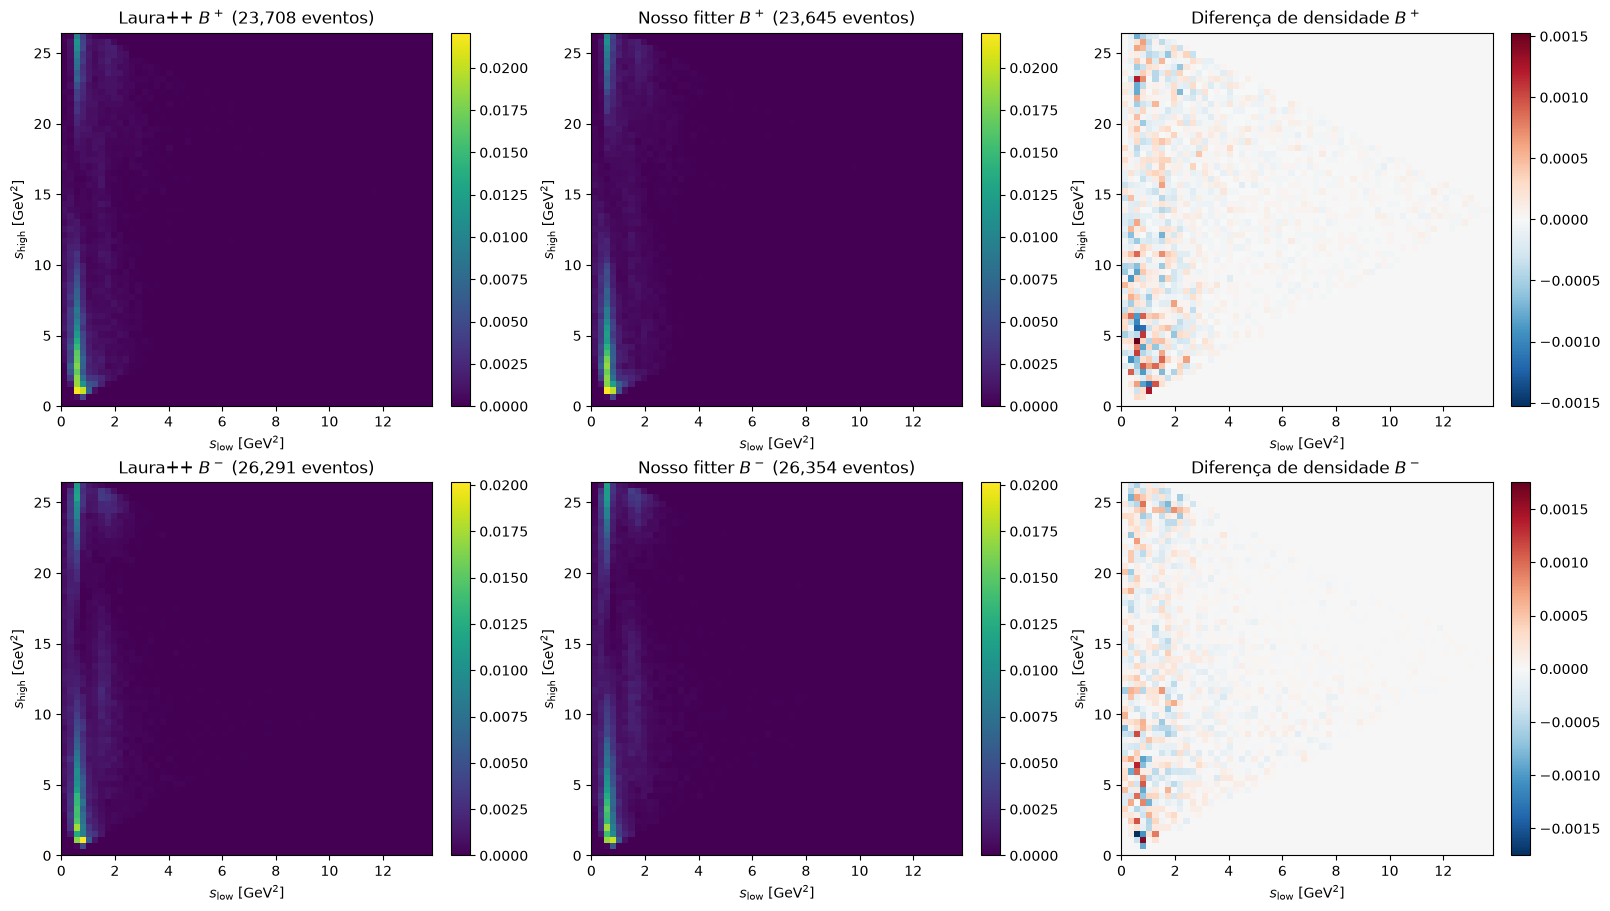

In [14]:
LAURA_COMPARISON_BINS = 60

def _folded(data):
    return (np.minimum(np.asarray(data.s13), np.asarray(data.s23)),
            np.maximum(np.asarray(data.s13), np.asarray(data.s23)))

_laura_pairs = (laura_plus_toy0, laura_minus_toy0)
_our_pairs = (our_plus_toy0, our_minus_toy0)
_all_low_high = [_folded(d) for d in (*_laura_pairs, *_our_pairs)]
_xmax = max(float(x.max()) for x, y in _all_low_high)
_ymax = max(float(y.max()) for x, y in _all_low_high)
edges_low = np.linspace(0, _xmax * 1.001, LAURA_COMPARISON_BINS + 1)
edges_high = np.linspace(0, _ymax * 1.001, LAURA_COMPARISON_BINS + 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for row, (charge, laura_data, our_data) in enumerate(zip(
    ("+", "-"), _laura_pairs, _our_pairs, strict=True
)):
    lx, ly = _folded(laura_data)
    ox, oy = _folded(our_data)
    laura_density = np.histogram2d(lx, ly, bins=(edges_low, edges_high))[0] / laura_data.size
    our_density = np.histogram2d(ox, oy, bins=(edges_low, edges_high))[0] / our_data.size
    vmax = max(laura_density.max(), our_density.max())
    diff = laura_density - our_density
    dmax = np.abs(diff).max()

    mesh0 = axes[row, 0].pcolormesh(edges_low, edges_high, laura_density.T,
                                    vmin=0, vmax=vmax, cmap="viridis", shading="auto")
    axes[row, 0].set_title(rf"Laura++ $B^{charge}$ ({laura_data.size:,} eventos)")
    mesh1 = axes[row, 1].pcolormesh(edges_low, edges_high, our_density.T,
                                    vmin=0, vmax=vmax, cmap="viridis", shading="auto")
    axes[row, 1].set_title(rf"Nosso fitter $B^{charge}$ ({our_data.size:,} eventos)")
    mesh2 = axes[row, 2].pcolormesh(edges_low, edges_high, diff.T,
                                    vmin=-dmax, vmax=dmax, cmap="RdBu_r", shading="auto")
    axes[row, 2].set_title(rf"Diferença de densidade $B^{charge}$")
    for ax, mesh in ((axes[row, 0], mesh0), (axes[row, 1], mesh1), (axes[row, 2], mesh2)):
        ax.set(xlabel=r"$s_{\rm low}$ [GeV$^2$]", ylabel=r"$s_{\rm high}$ [GeV$^2$]")
        fig.colorbar(mesh, ax=ax)
plt.show()


### Projeções dobradas: Laura++ vs. nosso fitter

Histogramas normalizados por densidade (área unitária), sobrepondo as duas amostras por carga. Como as contagens totais diferem, a comparação é feita em densidade, não em contagem absoluta.


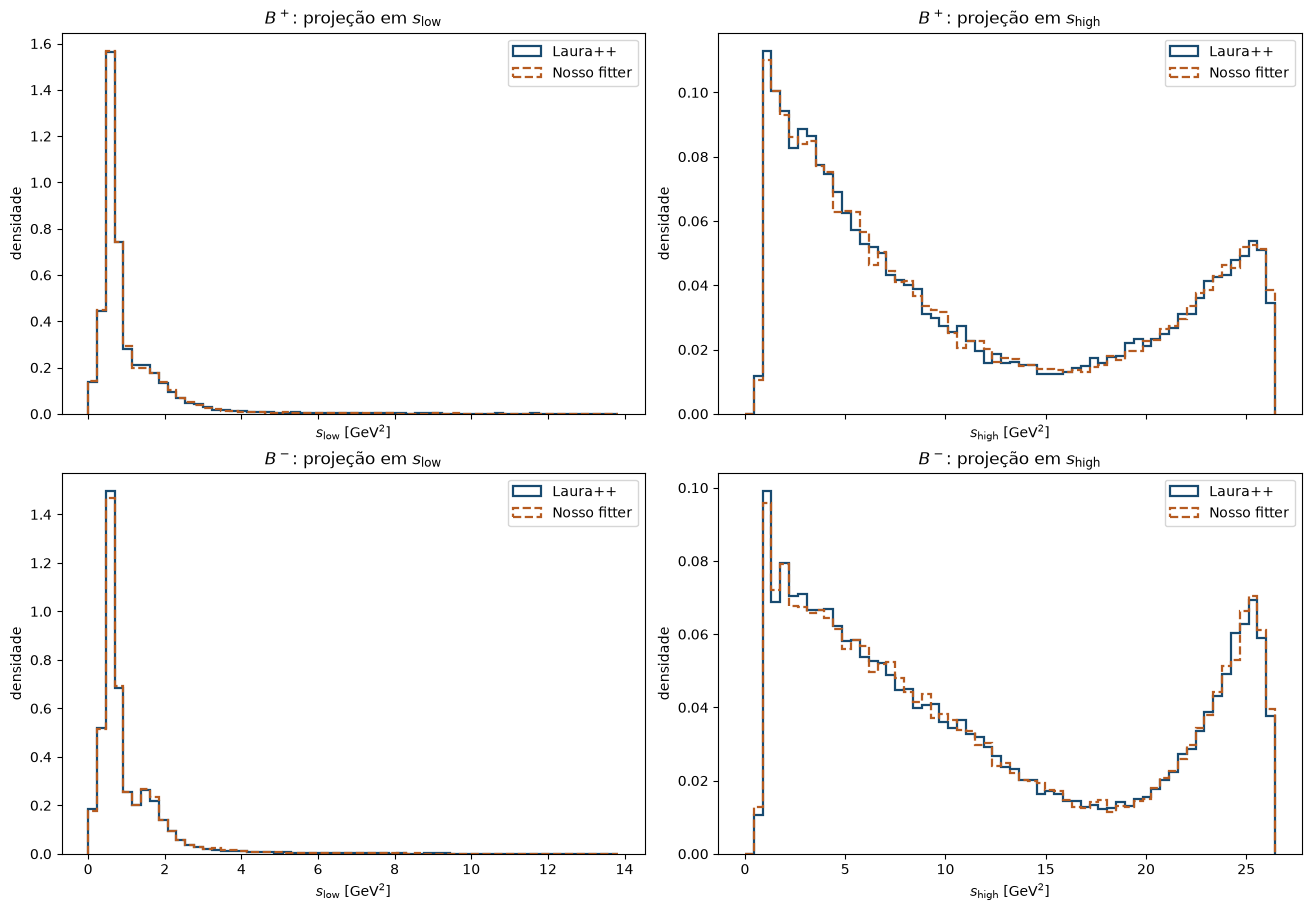

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True, sharex="col")
for col, (label, edges) in enumerate((("low", edges_low), ("high", edges_high))):
    for row, (charge, laura_data, our_data) in enumerate(zip(
        ("+", "-"), _laura_pairs, _our_pairs, strict=True
    )):
        lx, ly = _folded(laura_data)
        ox, oy = _folded(our_data)
        laura_values = lx if label == "low" else ly
        our_values = ox if label == "low" else oy
        ax = axes[row, col]
        ax.hist(laura_values, bins=edges, density=True, histtype="step",
               label="Laura++", color="#174a70", linewidth=1.6)
        ax.hist(our_values, bins=edges, density=True, histtype="step",
               label="Nosso fitter", color="#b65b20", linewidth=1.6, linestyle="--")
        ax.set(xlabel=rf"$s_{{\rm {label}}}$ [GeV$^2$]", ylabel="densidade",
               title=rf"$B^{charge}$: projeção em $s_{{\rm {label}}}$")
        ax.legend()
plt.show()


## Ajuste do ensemble de toys do Laura++

Cada `gen-3pi_toy{index}.root` é um toy independente do mesmo modelo, sem eficiência nem background (nível de geração). Ajustamos os coeficientes cartesianos com a mesma convenção de referência da seção de toy closure acima — `rho770.x=1`, `rho770.y=0`, `rho770.dy=0` fixos, `rho770.dx` e os demais 24 coeficientes livres — mas **sem fração de sinal nem formas de eficiência/background**, já que estas amostras não passaram por seleção.

O modelo de ajuste é construído uma única vez fora do laço (a malha de quadratura Square Dalitz não depende dos dados); apenas os dados e os caches de `CPFitSession` mudam a cada toy. Cada ajuste usa um start deslocado dos valores publicados com uma semente independente do índice do toy, e os resultados (validade, NLL, pulls) são registrados em `summary.csv`/`parameters.csv` sob `notebooks/benchmark/logs/`, no mesmo padrão usado pelos notebooks de `genfit/`.

`N_LAURA_TOYS_TO_FIT` controla quantos dos `N_LAURA_TOYS` arquivos disponíveis entram no ensemble desta execução — comece pequeno (dez toys já dá uma primeira leitura de recuperação) e aumente para um estudo estatístico de pulls; cada ajuste em resolução `LAURA_FIT_RESOLUTION` é caro.


In [16]:
from dataclasses import replace

from dalitzplotfitter import CPFitSession, CPRealImag, Parameter

LAURA_FIT_RESOLUTION = resolution  # reduza para um teste rápido; mantenha para fidelidade ao benchmark acima
N_LAURA_TOYS_TO_FIT = 99  # até N_LAURA_TOYS; comece pequeno, aumente para um ensemble completo
LAURA_START_SIGMA = 0.04
LAURA_START_SEED = 190905400
LAURA_NCALL = 20_000
LAURA_STRATEGY = 1
assert 1 <= N_LAURA_TOYS_TO_FIT <= N_LAURA_TOYS

laura_shared = {}
laura_truth = {}
for name, values in COEFFICIENTS.items():
    pars = tuple(
        Parameter.coefficient(
            f"{name}.{axis}", value, owner=name, step=0.01,
            fixed=(name == "rho770" and axis in ("x", "y", "dy")),
        )
        for axis, value in zip(("x", "y", "dx", "dy"), values, strict=True)
    )
    laura_shared[name] = CPRealImag(*pars)
    laura_truth.update({p.name: p.value for p in pars})


def make_laura_fit_model(charge):
    base = make_model(charge, LAURA_FIT_RESOLUTION)
    return DecayModel(
        base.channel,
        [replace(c, coefficient=laura_shared[c.name].for_charge(charge))
         for c in base.components],
        normalize_components=True, normalization_method="square-dalitz",
        normalization_resolution=LAURA_FIT_RESOLUTION,
        normalization_pair=(0, 1),
    )


laura_fit_plus = make_laura_fit_model(+1)
laura_fit_minus = make_laura_fit_model(-1)
laura_free_names = [p.name for p in laura_fit_plus.parameters + laura_fit_minus.parameters
                    if not p.fixed]
laura_free_names = list(dict.fromkeys(laura_free_names))  # nomes são compartilhados entre as cargas
print(f"Parâmetros livres por toy: {len(laura_free_names)}")


Parâmetros livres por toy: 25


In [17]:
from contextlib import redirect_stdout, redirect_stderr
from datetime import datetime, timezone
import json
import traceback
from time import perf_counter
from uuid import uuid4

run_id = "laura_toys_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ") + "_" + uuid4().hex[:8]
laura_log_dir = Path.cwd() / "logs" / run_id
laura_log_dir.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(LAURA_START_SEED)
laura_starts = [
    {name: laura_truth[name] + rng.normal(0.0, LAURA_START_SIGMA) for name in laura_free_names}
    for _ in range(N_LAURA_TOYS_TO_FIT)
]
config = dict(
    n_toys_available=N_LAURA_TOYS, n_toys_fitted=N_LAURA_TOYS_TO_FIT,
    resolution=LAURA_FIT_RESOLUTION, start_seed=LAURA_START_SEED,
    start_sigma=LAURA_START_SIGMA, ncall=LAURA_NCALL, strategy=LAURA_STRATEGY,
    laura_toy_dir=str(LAURA_TOY_DIR), truth=laura_truth,
)
(laura_log_dir / "config.json").write_text(
    json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(f"Logs desta execução: {laura_log_dir}")

laura_summary_rows = []
laura_parameter_rows = []
for toy_index in range(N_LAURA_TOYS_TO_FIT):
    t0 = perf_counter()
    log_path = laura_log_dir / f"toy_{toy_index:03d}.log"
    start_values = laura_starts[toy_index]
    with log_path.open("w", encoding="utf-8", buffering=1) as log:
        with redirect_stdout(log), redirect_stderr(log):
            print(f"toy_index={toy_index}, file={laura_toy_path(toy_index)}")
            print("start_values=" + json.dumps(start_values, sort_keys=True))
            try:
                plus_data, minus_data = load_laura_toy(toy_index)
                session = CPFitSession(laura_fit_plus, laura_fit_minus, plus_data, minus_data)
                truth_nll = float(session.objective(laura_truth))
                print(f"B+={plus_data.size}, B-={minus_data.size}, truth_nll={truth_nll:.9f}")
                result = session.fit(
                    dict(start_values), simplex=False, strategy=LAURA_STRATEGY,
                    hesse=True, ncall=LAURA_NCALL, verbose=2,
                )
                print(result)
                session.print_result(result)
                fit_values = session.result_values(result)
                failure = None
            except Exception as exc:
                traceback.print_exc()
                result = None
                truth_nll = np.nan
                failure = repr(exc)
            finally:
                print(f"elapsed_seconds={perf_counter()-t0:.6f}")
    if result is None:
        laura_summary_rows.append(dict(
            toy_index=toy_index, valid=False, nll=np.nan, truth_nll=truth_nll,
            nll_minus_truth=np.nan, seconds=perf_counter() - t0,
            exception=failure, log_file=str(log_path),
        ))
        print(f"Toy {toy_index}: falhou: {failure}; log: {log_path.name}", flush=True)
        continue
    laura_summary_rows.append(dict(
        toy_index=toy_index, valid=bool(result.valid), nll=float(result.fval),
        truth_nll=truth_nll, nll_minus_truth=float(result.fval) - truth_nll,
        edm=float(result.fmin.edm), nfcn=int(result.nfcn),
        accurate_covariance=bool(result.fmin.has_accurate_covar),
        posdef_covariance=bool(result.fmin.has_posdef_covar),
        seconds=perf_counter() - t0, exception="", log_file=str(log_path),
    ))
    for name in laura_free_names:
        error = float(result.errors[name])
        laura_parameter_rows.append(dict(
            toy_index=toy_index, parameter=name, truth=laura_truth[name],
            start=start_values[name], value=fit_values[name], error=error,
            pull=(fit_values[name] - laura_truth[name]) / error if error > 0 else np.nan,
        ))
    pd.DataFrame(laura_summary_rows).to_csv(laura_log_dir / "summary.csv", index=False)
    pd.DataFrame(laura_parameter_rows).to_csv(laura_log_dir / "parameters.csv", index=False)
    print(f"Toy {toy_index}: valid={result.valid}, NLL={result.fval:.6f}, "
          f"EDM={result.fmin.edm:.2e}", flush=True)

laura_summary = pd.DataFrame(laura_summary_rows).set_index("toy_index")
laura_parameters = pd.DataFrame(laura_parameter_rows)
laura_valid = laura_summary["valid"] & np.isfinite(laura_summary["nll"])
display(laura_summary)
print(f"Ajustes válidos: {laura_valid.sum()}/{N_LAURA_TOYS_TO_FIT}")


Logs desta execução: /home/juan-leite/Work/DalitzPlotFitter/notebooks/benchmark/logs/laura_toys_20260914T043841_880338Z_5914686d
Toy 0: valid=True, NLL=247749.244928, EDM=4.14e-08
Toy 1: valid=True, NLL=247980.132444, EDM=5.72e-08
Toy 2: valid=True, NLL=247688.629648, EDM=1.55e-07
Toy 3: valid=True, NLL=247513.206367, EDM=8.40e-08
Toy 4: valid=True, NLL=247735.535743, EDM=1.90e-08
Toy 5: valid=True, NLL=247241.773443, EDM=6.01e-08
Toy 6: valid=True, NLL=247950.519489, EDM=3.02e-08
Toy 7: valid=True, NLL=247998.919567, EDM=6.48e-09
Toy 8: valid=True, NLL=247947.839924, EDM=5.26e-08
Toy 9: valid=True, NLL=247982.172142, EDM=2.51e-08
Toy 10: valid=True, NLL=248138.406616, EDM=6.58e-09
Toy 11: valid=True, NLL=247739.895892, EDM=1.64e-07
Toy 12: valid=True, NLL=248375.885525, EDM=1.97e-08
Toy 13: valid=True, NLL=247914.623606, EDM=9.40e-08
Toy 14: valid=True, NLL=248791.548788, EDM=8.91e-08
Toy 15: valid=True, NLL=247990.058738, EDM=3.12e-08
Toy 16: valid=True, NLL=247729.068079, EDM=3.93e-

,valid,nll,truth_nll,nll_minus_truth,edm,nfcn,accurate_covariance,posdef_covariance,seconds,exception,log_file
toy_index,,,,,,,,,,,
0,True,247749.244928,247761.570983,-12.326056,4.142573e-08,1078,True,True,15.613822,,/home/juan-leite/Work/DalitzPlotFitter/noteboo...
1,True,247980.132444,247987.979846,-7.847402,5.722071e-08,1077,True,True,5.534277,,/home/juan-leite/Work/DalitzPlotFitter/noteboo...
2,True,247688.629648,247696.803805,-8.174157,1.548734e-07,1081,True,True,2.158927,,/home/juan-leite/Work/DalitzPlotFitter/noteboo...
3,True,247513.206367,247526.004507,-12.798140,8.398541e-08,1081,True,True,2.346039,,/home/juan-leite/Work/DalitzPlotFitter/noteboo...
4,True,247735.535743,247748.073562,-12.537819,1.902334e-08,1083,True,True,2.229299,,/home/juan-leite/Work/DalitzPlotFitter/noteboo...
...,...,...,...,...,...,...,...,...,...,...,...
94,True,248006.237615,248020.332283,-14.094667,1.242271e-07,1077,True,True,2.463229,,/home/juan-leite/Work/DalitzPlotFitter/noteboo...
95,True,247657.115740,247666.298872,-9.183132,5.211486e-09,1086,True,True,2.491146,,/home/juan-leite/Work/DalitzPlotFitter/noteboo...
96,True,247465.805687,247477.950971,-12.145284,6.267671e-08,1079,True,True,2.531703,,/home/juan-leite/Work/DalitzPlotFitter/noteboo...


Ajustes válidos: 99/99


### Diagnósticos do ensemble: recuperação dos coeficientes publicados

Pulls $= (\hat\theta-\theta_{\rm publicado})/\sigma_{\hat\theta}$ calculados apenas para ajustes válidos com erro HESSE positivo e finito. Média próxima de zero e desvio padrão próximo de um são a referência esperada para um ensemble suficientemente grande; `N_LAURA_TOYS_TO_FIT` pequeno serve apenas como primeira checagem, não como estudo de cobertura.


,n,mean_pull,std_pull,mean_value,mean_error
parameter,,,,,
f2_1270.dx,99,0.1129,1.0226,-0.0013,0.0057
f2_1270.dy,99,-0.1697,1.0279,-0.1799,0.0052
f2_1270.x,99,-0.0959,0.9316,0.2904,0.0058
f2_1270.y,99,0.1778,1.0099,0.2049,0.0053
omega782.dx,99,-0.1071,0.9272,-0.0005,0.0046
omega782.dy,99,0.0167,1.0691,-0.0219,0.0054
omega782.x,99,0.0583,0.9748,0.0913,0.0048
omega782.y,99,0.0581,1.0494,-0.0067,0.0054
rescattering.dx,99,0.0868,1.0486,-0.0466,0.0050


Toys válidos: 99/99


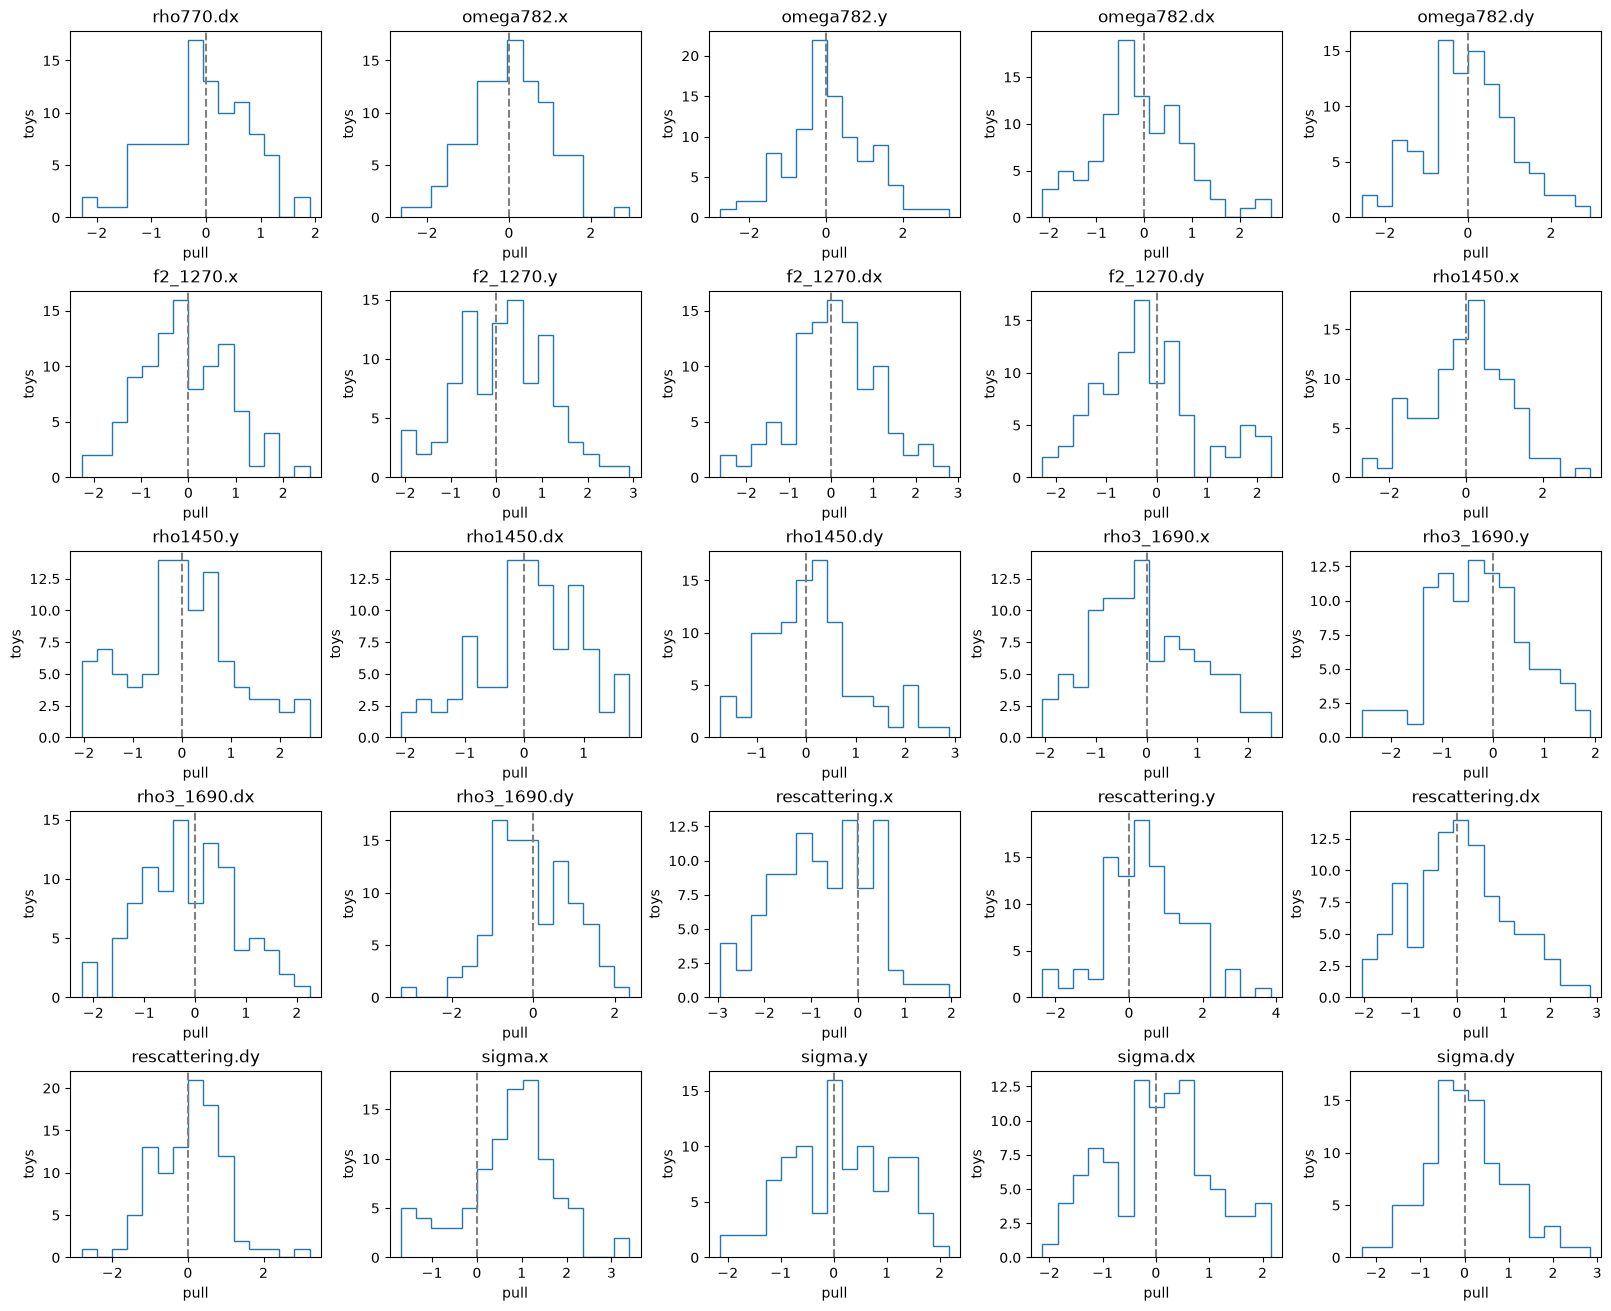

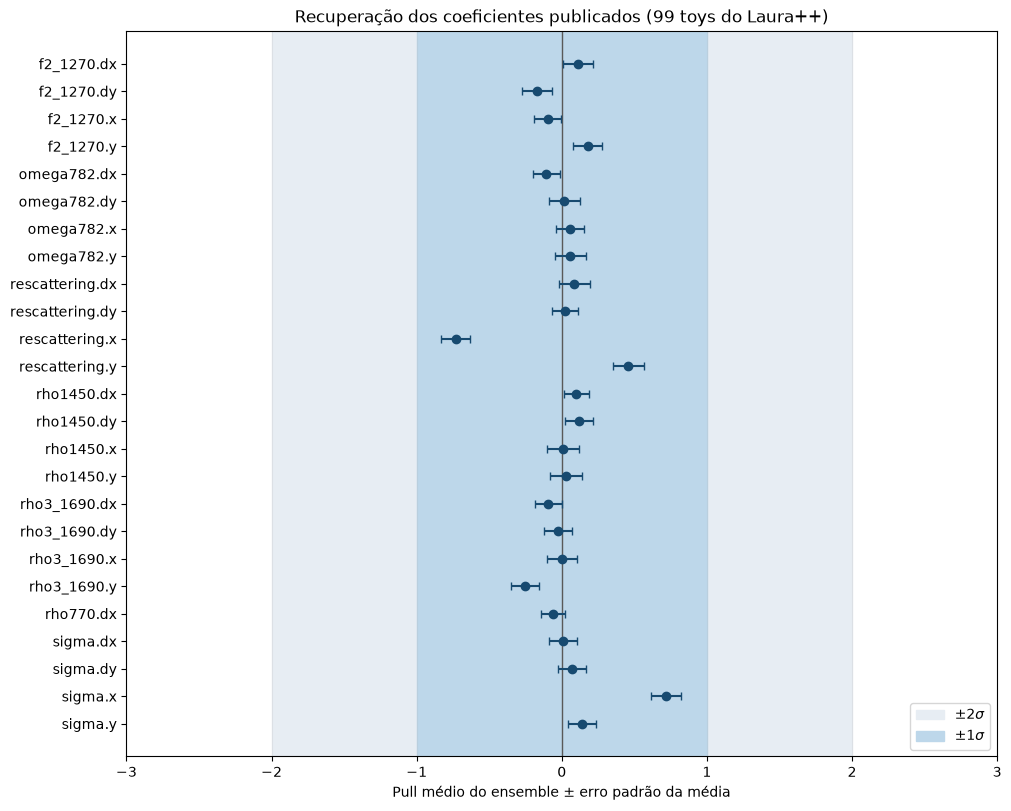

In [18]:
if laura_parameters.empty:
    print("Nenhum resultado disponível; consulte os logs de exceção em", laura_log_dir)
else:
    valid_ids = laura_summary.index[laura_valid]
    laura_selected = laura_parameters.loc[
        laura_parameters.toy_index.isin(valid_ids)
        & np.isfinite(laura_parameters.pull) & (laura_parameters.error > 0)
    ]
    laura_pull_summary = laura_selected.groupby("parameter").agg(
        n=("pull", "size"), mean_pull=("pull", "mean"),
        std_pull=("pull", "std"), mean_value=("value", "mean"),
        mean_error=("error", "mean"),
    )
    display(laura_pull_summary.round(4))
    laura_pull_summary.to_csv(laura_log_dir / "pull_summary.csv")
    print(f"Toys válidos: {len(valid_ids)}/{N_LAURA_TOYS_TO_FIT}")

    n_params = len(laura_free_names)
    n_cols = 5
    n_rows = -(-n_params // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.6 * n_rows), constrained_layout=True)
    for ax, name in zip(np.asarray(axes).flat, laura_free_names, strict=False):
        values = laura_selected.loc[laura_selected.parameter == name, "pull"]
        ax.hist(values, bins=min(15, max(5, len(values))), histtype="step")
        ax.axvline(0, color="grey", linestyle="--")
        ax.set(title=name, xlabel="pull", ylabel="toys")
    for ax in np.asarray(axes).flat[n_params:]:
        ax.axis("off")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
    positions = np.arange(len(laura_pull_summary))
    ax.axvspan(-2, 2, color="#e7edf3", label=r"$\pm2\sigma$")
    ax.axvspan(-1, 1, color="#bdd7ea", label=r"$\pm1\sigma$")
    ax.axvline(0, color="0.35", linewidth=1)
    ax.errorbar(laura_pull_summary["mean_pull"], positions,
               xerr=laura_pull_summary["std_pull"] / np.sqrt(np.maximum(laura_pull_summary["n"], 1)),
               fmt="o", capsize=3, color="#174a70", zorder=3)
    ax.set_yticks(positions, laura_pull_summary.index)
    ax.invert_yaxis()
    limit = max(3.0, float(laura_pull_summary["mean_pull"].abs().max()) + 0.4)
    ax.set(xlim=(-limit, limit), xlabel=r"Pull médio do ensemble $\pm$ erro padrão da média",
           title=f"Recuperação dos coeficientes publicados ({len(valid_ids)} toys do Laura++)")
    ax.grid(axis="x", alpha=0.2)
    ax.legend(loc="lower right")
    plt.show()
